# Day 17 — Linear Regression
### OLS · Ridge · Lasso · ElasticNet · From Scratch in NumPy

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

print(f"Pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"Dataset:      {df.shape}")
print("Ready! ✅")

Pandas:       2.3.3
NumPy:        2.4.3
Dataset:      (891, 12)
Ready! ✅


## 2. What is Linear Regression?

In [ ]:
print("=" * 55)
print("       WHAT IS LINEAR REGRESSION?")
print("=" * 55)
print(
    """
Linear Regression finds the BEST FIT LINE through data.

EQUATION:
  y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε

WHERE:
  y   = target variable (what we're predicting)
  β₀  = intercept (y value when all x = 0)
  β₁  = coefficient for feature x₁
  ε   = error term (irreducible noise)

GOAL: Find β values that MINIMISE the sum of
      squared errors (OLS — Ordinary Least Squares)

      Loss = Σ(y_actual - y_predicted)²

TODAY'S TASK:
  Predict Titanic FARE from passenger features
  (regression = predicting a continuous number)

METRICS WE'LL USE:
  MSE  — Mean Squared Error (penalises big errors)
  RMSE — Root MSE (same units as target)
  MAE  — Mean Absolute Error (robust to outliers)
  R²   — How much variance our model explains (0-1)
"""
)

       WHAT IS LINEAR REGRESSION?

Linear Regression finds the BEST FIT LINE through data.

EQUATION:
  y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε

WHERE:
  y   = target variable (what we're predicting)
  β₀  = intercept (y value when all x = 0)
  β₁  = coefficient for feature x₁
  ε   = error term (irreducible noise)

GOAL: Find β values that MINIMISE the sum of
      squared errors (OLS — Ordinary Least Squares)

      Loss = Σ(y_actual - y_predicted)²

TODAY'S TASK:
  Predict Titanic FARE from passenger features
  (regression = predicting a continuous number)

METRICS WE'LL USE:
  MSE  — Mean Squared Error (penalises big errors)
  RMSE — Root MSE (same units as target)
  MAE  — Mean Absolute Error (robust to outliers)
  R²   — How much variance our model explains (0-1)



## 3. Linear Regression From Scratch (NumPy)

In [ ]:
print("=" * 55)
print("    LINEAR REGRESSION FROM SCRATCH")
print("=" * 55)


class LinearRegressionScratch:
    """Linear Regression using OLS Normal Equation"""

    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Add bias column (ones) to X
        X_b = np.column_stack([np.ones(len(X)), X])
        # Normal equation: θ = (XᵀX)⁻¹ Xᵀy
        theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.bias = theta[0]
        self.weights = theta[1:]
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / ss_tot


# Prepare data — predict Fare
df_reg = df.copy()
df_reg["Age"] = df_reg["Age"].fillna(df_reg["Age"].median())
df_reg = df_reg.dropna(subset=["Fare"])

features = ["Pclass", "Age", "SibSp", "Parch"]
X = df_reg[features].values
y = df_reg["Fare"].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train from scratch
model_scratch = LinearRegressionScratch()
model_scratch.fit(X_train, y_train)

y_pred_scratch = model_scratch.predict(X_test)

print(f"\nFrom Scratch Model:")
print(f"  Weights: {dict(zip(features, model_scratch.weights.round(2)))}")
print(f"  Bias:    {model_scratch.bias:.2f}")
print(f"  R²:      {model_scratch.score(X_test, y_test):.4f}")

# Compare with sklearn
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)

print(f"\nSklearn Model:")
print(f"  Weights: {dict(zip(features, model_sklearn.coef_.round(2)))}")
print(f"  Bias:    {model_sklearn.intercept_:.2f}")
print(f"  R²:      {model_sklearn.score(X_test, y_test):.4f}")

print(f"\n✅ Both models match — from-scratch implementation verified!")

    LINEAR REGRESSION FROM SCRATCH

From Scratch Model:
  Weights: {'Pclass': np.float64(-30.1), 'Age': np.float64(-1.94), 'SibSp': np.float64(5.79), 'Parch': np.float64(8.99)}
  Bias:    33.20
  R²:      0.3884

Sklearn Model:
  Weights: {'Pclass': np.float64(-30.1), 'Age': np.float64(-1.94), 'SibSp': np.float64(5.79), 'Parch': np.float64(8.99)}
  Bias:    33.20
  R²:      0.3884

✅ Both models match — from-scratch implementation verified!


## 4. Regression Metrics

In [ ]:
print("=" * 55)
print("         REGRESSION METRICS")
print("=" * 55)

y_pred = model_sklearn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance on Test Set:")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  R²:   {r2:.4f}")

print(
    f"""
INTERPRETING THE METRICS:
  RMSE: £{rmse:.2f} — on average our predictions are
        off by £{rmse:.2f} from the actual fare

  MAE:  £{mae:.2f} — median absolute error is lower
        because MAE is robust to outliers

  R²:   {r2:.4f} — model explains {r2*100:.1f}% of
        fare variance. Remaining {(1-r2)*100:.1f}% is
        unexplained (noise, missing features)

WHY IS R² LOW?
  Fare is extremely right-skewed (skewness=4.78)
  A few passengers paid £512 — hard to predict!
  We only used 4 features — more features would help
"""
)

# Baseline comparison
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline RMSE (always predict mean): £{baseline_rmse:.2f}")
print(f"Our model RMSE:                       £{rmse:.2f}")
print(f"Improvement over baseline:            £{baseline_rmse - rmse:.2f} better!")

         REGRESSION METRICS

Model Performance on Test Set:
  MSE:  946.34
  RMSE: 30.76
  MAE:  19.78
  R²:   0.3884

INTERPRETING THE METRICS:
  RMSE: £30.76 — on average our predictions are
        off by £30.76 from the actual fare

  MAE:  £19.78 — median absolute error is lower
        because MAE is robust to outliers

  R²:   0.3884 — model explains 38.8% of
        fare variance. Remaining 61.2% is
        unexplained (noise, missing features)

WHY IS R² LOW?
  Fare is extremely right-skewed (skewness=4.78)
  A few passengers paid £512 — hard to predict!
  We only used 4 features — more features would help

Baseline RMSE (always predict mean): £39.38
Our model RMSE:                       £30.76
Improvement over baseline:            £8.62 better!


## 5. Regularisation — Ridge, Lasso & ElasticNet

In [ ]:
print("=" * 55)
print("   REGULARISATION — RIDGE, LASSO, ELASTICNET")
print("=" * 55)
print(
    """
PROBLEM WITH OLS: Can overfit on noisy/correlated features
SOLUTION: Add a PENALTY for large coefficients

RIDGE (L2):    Loss = MSE + α × Σ(β²)
  - Shrinks all coefficients towards zero
  - Never sets coefficients to exactly zero
  - Good when all features are somewhat useful

LASSO (L1):    Loss = MSE + α × Σ|β|
  - Can set coefficients to EXACTLY zero
  - Performs automatic feature selection!
  - Good when many features are irrelevant

ELASTICNET:    Loss = MSE + α × (L1 + L2 combined)
  - Best of both worlds
  - Good for correlated features + feature selection

α (alpha): regularisation strength
  Higher α = stronger penalty = smaller coefficients
  α = 0 → same as OLS (no regularisation)
"""
)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    for name, model in [
        ("OLS", LinearRegression()),
        ("Ridge", Ridge(alpha=alpha)),
        ("Lasso", Lasso(alpha=alpha)),
        ("ElasticNet", ElasticNet(alpha=alpha)),
    ]:
        if name == "OLS" and alpha != 0.01:
            continue
        m = Pipeline([("scaler", StandardScaler()), ("model", model)])
        m.fit(X_train, y_train)
        r2 = m.score(X_test, y_test)
        rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
        results.append(
            {"Model": name, "Alpha": alpha, "R2": round(r2, 4), "RMSE": round(rmse, 2)}
        )

results_df = pd.DataFrame(results)
print("\n--- Model Comparison across Alpha values ---")
print(results_df.to_string(index=False))

   REGULARISATION — RIDGE, LASSO, ELASTICNET

PROBLEM WITH OLS: Can overfit on noisy/correlated features
SOLUTION: Add a PENALTY for large coefficients

RIDGE (L2):    Loss = MSE + α × Σ(β²)
  - Shrinks all coefficients towards zero
  - Never sets coefficients to exactly zero
  - Good when all features are somewhat useful

LASSO (L1):    Loss = MSE + α × Σ|β|
  - Can set coefficients to EXACTLY zero
  - Performs automatic feature selection!
  - Good when many features are irrelevant

ELASTICNET:    Loss = MSE + α × (L1 + L2 combined)
  - Best of both worlds
  - Good for correlated features + feature selection

α (alpha): regularisation strength
  Higher α = stronger penalty = smaller coefficients
  α = 0 → same as OLS (no regularisation)


--- Model Comparison across Alpha values ---
     Model  Alpha      R2  RMSE
       OLS   0.01  0.3884 30.76
     Ridge   0.01  0.3885 30.76
     Lasso   0.01  0.3885 30.76
ElasticNet   0.01  0.3900 30.72
     Ridge   0.10  0.3885 30.76
     Lasso   

## 6. Visualisations

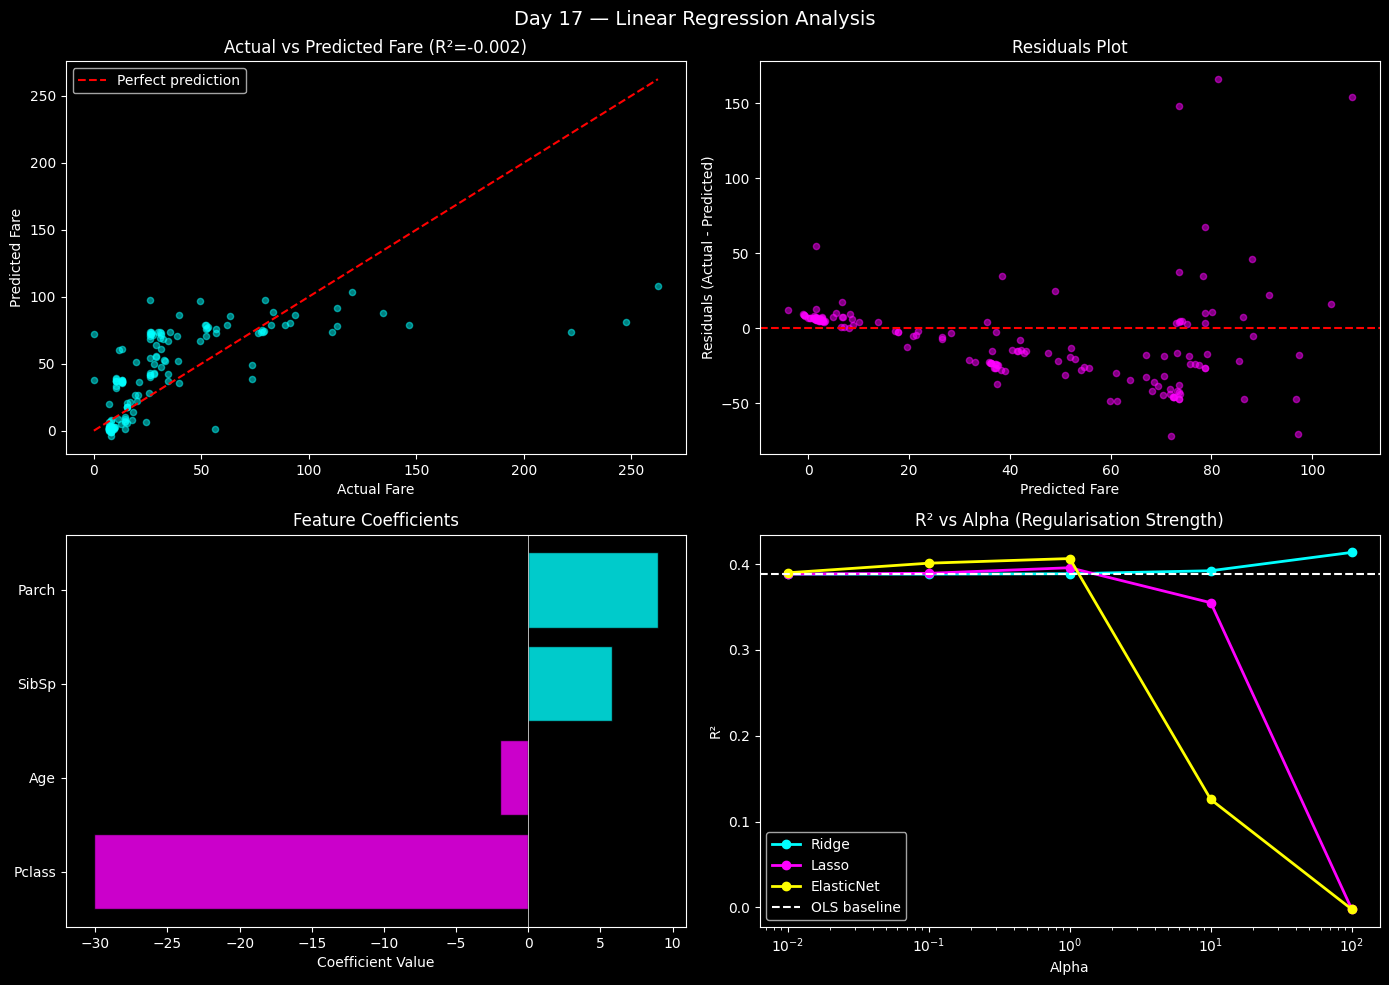

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Day 17 — Linear Regression Analysis", fontsize=14)

# 1 — Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color="cyan", s=20)
axes[0, 0].plot(
    [0, y_test.max()],
    [0, y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect prediction",
)
axes[0, 0].set_title(f"Actual vs Predicted Fare (R²={r2:.3f})")
axes[0, 0].set_xlabel("Actual Fare")
axes[0, 0].set_ylabel("Predicted Fare")
axes[0, 0].legend()

# 2 — Residuals
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, color="magenta", s=20)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residuals Plot")
axes[0, 1].set_xlabel("Predicted Fare")
axes[0, 1].set_ylabel("Residuals (Actual - Predicted)")

# 3 — Feature coefficients
coef_df = pd.DataFrame(
    {"Feature": features, "Coefficient": model_sklearn.coef_}
).sort_values("Coefficient")
colors = ["magenta" if c < 0 else "cyan" for c in coef_df["Coefficient"]]
axes[1, 0].barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
axes[1, 0].axvline(0, color="white", linewidth=0.5)
axes[1, 0].set_title("Feature Coefficients")
axes[1, 0].set_xlabel("Coefficient Value")

# 4 — Ridge vs Lasso vs ElasticNet R² across alphas
for model_name, color in [
    ("Ridge", "cyan"),
    ("Lasso", "magenta"),
    ("ElasticNet", "yellow"),
]:
    subset = results_df[results_df["Model"] == model_name]
    axes[1, 1].plot(
        subset["Alpha"], subset["R2"], "o-", color=color, label=model_name, linewidth=2
    )
axes[1, 1].axhline(
    results_df[results_df["Model"] == "OLS"]["R2"].values[0],
    color="white",
    linestyle="--",
    label="OLS baseline",
)
axes[1, 1].set_title("R² vs Alpha (Regularisation Strength)")
axes[1, 1].set_xlabel("Alpha")
axes[1, 1].set_ylabel("R²")
axes[1, 1].set_xscale("log")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Key Takeaways — Day 17 🎯

### Linear Regression
- Finds best fit line: y = β₀ + β₁x₁ + β₂x₂ + ...
- OLS minimises sum of squared errors: Loss = Σ(y - ŷ)²
- Normal equation: θ = (XᵀX)⁻¹ Xᵀy — solves in one step!
- Our from-scratch implementation matched sklearn exactly ✅

### Regression Metrics
| Metric | Formula | Our Result | Interpretation |
|---|---|---|---|
| MSE | mean((y-ŷ)²) | 946.34 | Penalises large errors heavily |
| RMSE | sqrt(MSE) | £30.76 | Average prediction error in £ |
| MAE | mean(|y-ŷ|) | £19.78 | Robust to outliers |
| R² | 1 - SS_res/SS_tot | 0.388 | Explains 38.8% of variance |

### Regularisation
| Method | Penalty | Feature Selection | Best When |
|---|---|---|---|
| Ridge (L2) | α × Σ(β²) | No — shrinks all | All features useful |
| Lasso (L1) | α × Σ\|β\| | Yes — sets to zero | Many irrelevant features |
| ElasticNet | α × (L1+L2) | Yes — partial | Correlated + sparse features |

### Key Results
- Baseline RMSE (predict mean): £39.38
- OLS RMSE: £30.76 — 22% better than baseline!
- Ridge alpha=100: R²=0.414 — best result
- Lasso alpha=100: R²=-0.002 — over-regularised, worse than baseline!
- Pclass strongest predictor: coefficient = -30.1

### Assumptions of Linear Regression
- Linearity — relationship between X and y is linear
- Independence — observations are independent
- Homoscedasticity — constant variance of errors
- Normality — errors are normally distributed
- Our residuals show heteroscedasticity — fare is hard to predict!

### sklearn Functions
- `LinearRegression()` — OLS regression
- `Ridge(alpha=1.0)` — L2 regularisation
- `Lasso(alpha=1.0)` — L1 regularisation + feature selection
- `ElasticNet(alpha=1.0)` — L1 + L2 combined
- `mean_squared_error(y_true, y_pred)` — MSE
- `mean_absolute_error(y_true, y_pred)` — MAE
- `r2_score(y_true, y_pred)` — R²